# 02 — Feature Engineering

Building on the EDA findings, this notebook cleans the raw data and constructs domain-driven engineered features, then previews their relationship with churn.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data
from src.feature_engineering import add_engineered_features

%matplotlib inline
pd.set_option('display.max_columns', None)


## 1. Load & Clean Raw Data

In [2]:
raw_df = load_raw_data()
clean_df = clean_raw_data(raw_df)
print(f'Raw shape: {raw_df.shape} -> Clean shape: {clean_df.shape}')
clean_df.head()


2026-07-31 14:22:17 | INFO     | src.data_loader | Loading raw data from C:\Users\ONJ3KOR\Work\Niteesh\customer-churn-prediction-ml\data\raw\Telco-Customer-Churn.csv


2026-07-31 14:22:17 | INFO     | src.data_loader | Loaded dataset with shape (7043, 21)


2026-07-31 14:22:17 | INFO     | src.preprocessing | Found 11 missing TotalCharges values (new customers with 0 tenure); filling with 0.


2026-07-31 14:22:17 | INFO     | src.preprocessing | Dropped 22 duplicate rows.


Raw shape: (7043, 21) -> Clean shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


`clean_raw_data` coerces `TotalCharges` to numeric (filling the 11 missing values with 0), drops `customerID`, and encodes `Churn` as 1/0. See `src/preprocessing.py` for the implementation.

## 2. Engineered Features

We derive six new features purely from existing raw columns (no leakage risk — every transformation is row-wise):

| Feature | Description |
|---|---|
| `TenureGroup` | Bucketed tenure: 0-12, 13-24, 25-48, 49-60, 61-72 months |
| `ContractLengthCategory` | Month-to-month -> Short-term; One/Two year -> Long-term |
| `AvgMonthlySpend` | `TotalCharges / max(tenure, 1)` — historical average spend |
| `TotalServicesCount` | Count of subscribed add-on/telecom services |
| `HasInternetService` | Yes/No flag derived from `InternetService` |
| `IsSeniorCitizen` | Readable Yes/No version of the raw 0/1 `SeniorCitizen` flag |


In [3]:
engineered_df = add_engineered_features(clean_df)
new_cols = ['TenureGroup', 'ContractLengthCategory', 'AvgMonthlySpend',
            'TotalServicesCount', 'HasInternetService', 'IsSeniorCitizen']
engineered_df[new_cols].head(10)


2026-07-31 14:22:17 | INFO     | src.feature_engineering | Adding engineered features...


2026-07-31 14:22:17 | INFO     | src.feature_engineering | Feature engineering complete. New shape: (7021, 25)


,TenureGroup,ContractLengthCategory,AvgMonthlySpend,TotalServicesCount,HasInternetService,IsSeniorCitizen
0,0-12,Short-term,29.85,1,Yes,No
1,25-48,Long-term,55.57,3,Yes,No
2,0-12,Short-term,54.08,3,Yes,No
3,25-48,Long-term,40.91,3,Yes,No
4,0-12,Short-term,75.82,1,Yes,No
5,0-12,Short-term,102.56,5,Yes,No
6,13-24,Short-term,88.61,4,Yes,No
7,0-12,Short-term,30.19,1,Yes,No
8,25-48,Short-term,108.79,6,Yes,No
9,61-72,Long-term,56.26,3,Yes,No


### 2.1 TenureGroup vs. Churn

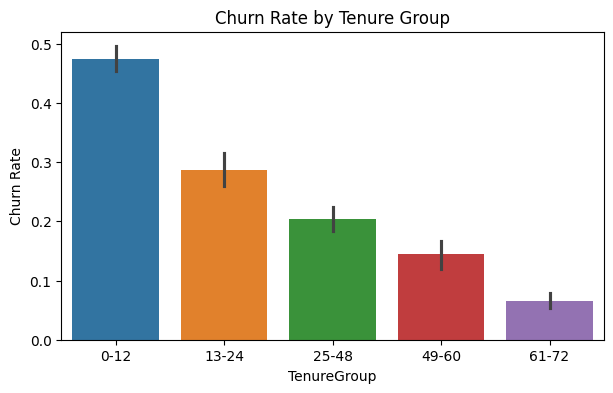

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=engineered_df, x='TenureGroup', y='Churn', ax=ax, hue='TenureGroup', legend=False)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Tenure Group')
plt.show()


**Insight:** Churn rate drops sharply as tenure increases — customers in their first year churn far more often than long-tenured customers, confirming `TenureGroup` is a useful, more interpretable bucketing of the raw `tenure` value.

### 2.2 ContractLengthCategory vs. Churn

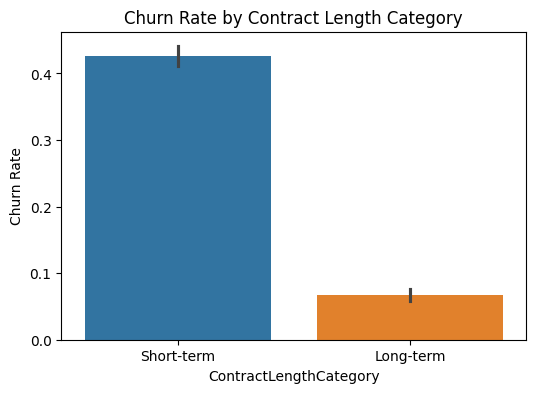

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=engineered_df, x='ContractLengthCategory', y='Churn', ax=ax, hue='ContractLengthCategory', legend=False)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Contract Length Category')
plt.show()


**Insight:** Short-term (month-to-month) customers churn at a much higher rate than long-term contract holders — this collapsed binary view captures most of the signal in the original 3-level `Contract` column with less sparsity.

### 2.3 TotalServicesCount vs. Churn

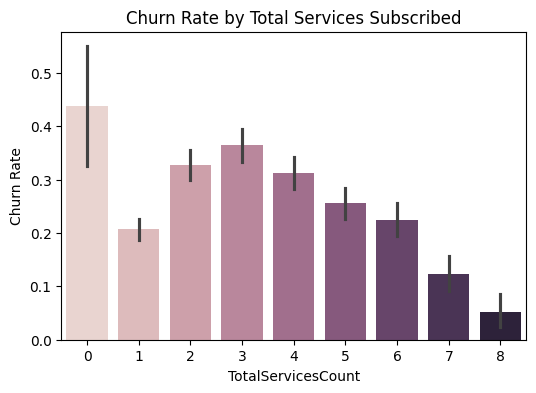

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=engineered_df, x='TotalServicesCount', y='Churn', ax=ax, hue='TotalServicesCount', legend=False)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Total Services Subscribed')
plt.show()


**Insight:** Customers with very few subscribed services churn more — bundling services appears to correlate with retention, possibly reflecting deeper engagement or switching costs.

### 2.4 AvgMonthlySpend vs. Churn

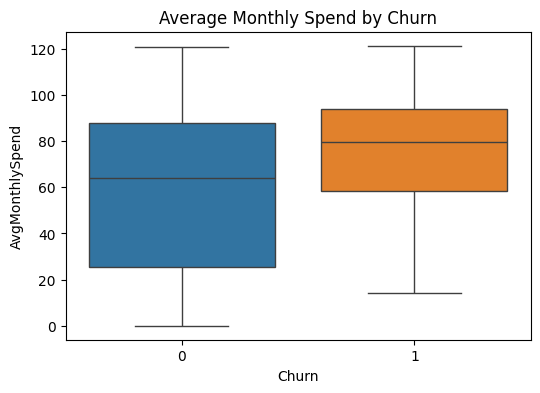

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=engineered_df, x='Churn', y='AvgMonthlySpend', ax=ax, hue='Churn', legend=False)
ax.set_title('Average Monthly Spend by Churn')
plt.show()


**Insight:** Churned customers show a slightly higher and more variable average monthly spend, consistent with price sensitivity as a churn driver.

## 3. Final Engineered Feature Set

In [8]:
print('Columns after feature engineering:')
print(list(engineered_df.columns))
print(f'\nFinal shape: {engineered_df.shape}')


Columns after feature engineering:
['gender', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'ContractLengthCategory', 'AvgMonthlySpend', 'TotalServicesCount', 'HasInternetService', 'IsSeniorCitizen']

Final shape: (7021, 25)


## 4. Summary

The engineered dataset combines the original service/account attributes with six new interpretable features. This combined feature set feeds directly into the `ColumnTransformer` built in `src/preprocessing.py` (imputation, one-hot encoding, and scaling) ahead of model training in `03_Model_Training.ipynb`.